In [303]:
import pandas as pd
import matplotlib.pyplot as plt

In [304]:
df=pd.read_csv("student_exam_data_v1.csv")

In [305]:
df.head()

,study_hours,exam_score
0,4.4,59
1,9.6,98
2,7.6,82
3,6.4,69
4,2.4,42


In [306]:
df.tail()

,study_hours,exam_score
495,4.2,55
496,6.3,69
497,1.7,44
498,9.8,95
499,9.9,99


In [307]:
df.isna().sum()

study_hours    0
exam_score     0
dtype: int64

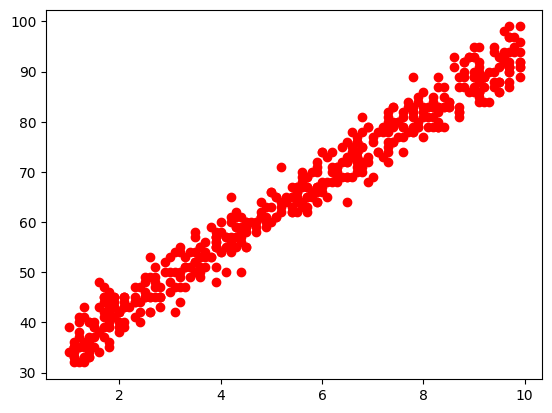

In [308]:
x=df[["study_hours"]]
y=df["exam_score"]
plt.scatter(x,y,color="r")

In [309]:
x=df.drop(columns="exam_score")
y=df["exam_score"]

In [310]:
from sklearn.model_selection import train_test_split

In [311]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [312]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.03
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [313]:
y_pred=model.predict(x_test)
y_pred

array([73.78042868, 83.65138835, 39.56110183, 50.09012547, 89.57396415,
       56.01270128, 36.92884591, 49.4320615 , 40.2191658 , 81.67719642,
       77.72881255, 56.01270128, 58.64495719, 54.03850934, 36.92884591,
       80.36106846, 56.67076525, 71.80623675, 59.96108514, 88.91590018,
       62.59334106, 72.46430073, 88.2578362 , 36.92884591, 81.01913244,
       73.78042868, 40.2191658 , 76.41268459, 73.1223647 , 38.24497387,
       94.180412  , 86.28364426, 40.87722978, 48.77399752, 79.04494051,
       42.19335774, 40.87722978, 81.67719642, 44.82561365, 56.67076525,
       79.04494051, 69.17398084, 88.91590018, 74.43849266, 91.54815609,
       40.2191658 , 57.98689321, 92.86428404, 61.93527708, 52.72238139,
       35.61271796, 90.23202813, 48.77399752, 54.69657332, 73.1223647 ,
       90.23202813, 38.90303785, 61.2772131 , 71.80623675, 56.67076525,
       63.25140503, 44.16754967, 52.06431741, 72.46430073, 42.19335774,
       61.93527708, 68.51591686, 54.03850934, 73.78042868, 59.96

In [314]:
print(y_test)

361    71
73     80
374    38
155    47
104    89
       ..
347    33
86     74
75     79
438    76
15     45
Name: exam_score, Length: 100, dtype: int64


In [315]:
model.predict([[1.2]])

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36.92884591])

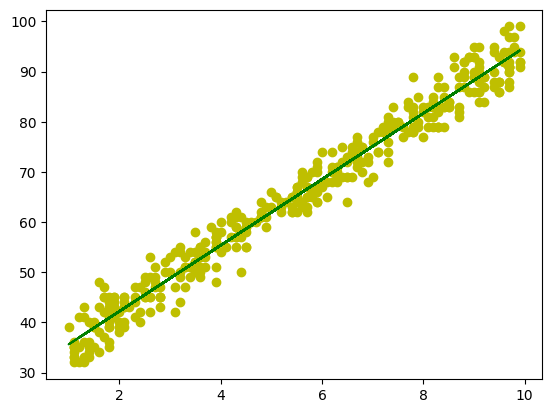

In [316]:
plt.scatter(x_train,y_train,color="y")
plt.plot(x_test,y_pred,color="g")

In [317]:
print(model.coef_)

[6.58063978]


In [318]:
print(model.intercept_)

29.032078177061152


In [319]:
df1=pd.DataFrame({"actual":y_test,"predicted":y_pred,"error":y_test-y_pred})
df1

,actual,predicted,error
361,71,73.780429,-2.780429
73,80,83.651388,-3.651388
374,38,39.561102,-1.561102
155,47,50.090125,-3.090125
104,89,89.573964,-0.573964
...,...,...,...
347,33,38.244974,-5.244974
86,74,79.044941,-5.044941
75,79,79.044941,-0.044941
438,76,77.728813,-1.728813


In [320]:
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score

In [321]:
print(mean_absolute_percentage_error(y_pred,y_test))

0.04061190439760418


In [322]:
print(mean_squared_error(y_pred,y_test))

9.631577493654875


In [323]:
print(root_mean_squared_error(y_pred,y_test))

3.10347828954141


In [324]:
print(r2_score(y_pred,y_test))

0.967836538354992
